In [1]:
import os
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation
import seaborn as sns
import cupy as cp  
import time
from scipy.interpolate import RectBivariateSpline, RegularGridInterpolator
from scipy.integrate import simpson 
from ipywidgets import interact, IntSlider

In [2]:
#file paths
DATA_DIR = r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2"

#files for longitudinal estimation
SIM_FILES_Longitudinal_Estimation = {
    "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_0\t_array.csv",
    "freq": r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_0\delz_MHz.csv",
    "data": r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_0\transHport_t_vs_Bz_delx_0.01_dely_0.1.csv"
}

#files for y field estimation
SIM_FILES_CONFIG_Y_Estimation = {
    "time": os.path.join(DATA_DIR, "t_array.csv"),
    "freq": os.path.join(DATA_DIR, "delz_MHz.csv"),
    "by_vals": os.path.join(DATA_DIR, "dely_MHz.csv"),
    # MUST be in the same order as By_values.csv
    "intensities": [
        os.path.join(DATA_DIR, "transH_t_vs_Bz_alpha2500_delx_0_dely_0.csv"),
        os.path.join(DATA_DIR, "transH_t_vs_Bz_alpha2500_delx_0_dely_0.1.csv"),
        os.path.join(DATA_DIR, "transH_t_vs_Bz_alpha2500_delx_0_dely_0.2.csv"),
        os.path.join(DATA_DIR, "transH_t_vs_Bz_alpha2500_delx_0_dely_0.3.csv"),
        os.path.join(DATA_DIR, "transH_t_vs_Bz_alpha2500_delx_0_dely_0.4.csv"),
        os.path.join(DATA_DIR, "transH_t_vs_Bz_alpha2500_delx_0_dely_0.5.csv")
    ]
}

#experimental data
EXP_FILES ={
    "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\t_exp.csv",
    "freq_axis": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Y_MHz_Exp.csv",
    "data": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Probe_trans_Exp.csv"
}

Test = 4
new_dir = f"Tests/Actual/CW/Test_{Test}_Sim"
new_dir_y = f"Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}"
os.makedirs(new_dir, exist_ok=True)
os.makedirs(new_dir_y, exist_ok=True)

In [3]:
#z field estimation parameters
#note: i use B_unk even though we are actually characterising f_unk, a gyromagnetic ratio factor is required to convert
B_UNK_BOUND = 1
B_UNK_INITIAL_RANGE = (-B_UNK_BOUND, B_UNK_BOUND) 
INITIAL_RESOLUTION  = 0.001
SIGMA_NOISE = 0.05 

#y field estimation parameters
fixed_bz_estimate = 0.0752
b_y_bounds = (0,0.5)
initial_res_by = 0.00025

F_BIAS_OFFSET_NUISANCE = 0
#pulse on threshold, need to align both  the  graphs to t=0
SIM_PULSE_THRESH = 0.2
EXP_PULSE_THRESH = 0.2

In [4]:
#Adaptive experiment parameters
T_STEP = 0.2 #FIXME: Number of time  point we have/ number of times we wanna loop, so change this value
MAX_TIME = 30 #FIXME: we have the data, just look and paste
KL_Y_GRID_SIZE = 100 #number of points under consideration for KL divergence expectation over hypothetical signal

In [5]:
#Adaptive zoom parameter
ZOOM_FACTOR = 2.5
ZOOM_TRIGGER_RATIO = 0.2
global ZOOM_TRIGGER_MULTIPLE
ZOOM_TRIGGER_MULTIPLE = 400
#ZOOM_WINDOW_FACTOR  =  100

In [6]:
#Data loading and pre-processing
def load_simulation(files):
    to = time.time()
    print(f"Loading Simulation from {files['data']}...")
    t = pd.read_csv(files['time'], header = None).values.flatten()
    f = pd.read_csv(files['freq'], header  = None).values.flatten()
    d = pd.read_csv(files['data'], header = None).values

    if d.shape != (len(t),len(f)):
        d = d.T

    d= calibration(d, np.min(d), np.max(d))
    spline = RectBivariateSpline(t, f, d, kx = 1, ky = 1)
    print(time.time()-to, "was the time taken to load sim data.")

    return  t,f,spline

def load_simulation_cube(config):
    print("...Loading Simulation Cube Data...")
    to = time.time()
    t_axis = pd.read_csv(config['time'], header=None).values.flatten()
    f_axis = pd.read_csv(config['freq'], header=None).values.flatten()
    by_axis = pd.read_csv(config['by_vals'], header=None).values.flatten()

    print(f"  > Axes Loaded: Time[{len(t_axis)}], Freq[{len(f_axis)}], By[{len(by_axis)}]")

    matrix_list = []
    for fname in config['intensities']:
        data =  pd.read_csv(fname, header=None).values

        if data.shape != (len(t_axis), len(f_axis)):
            data = data.T
        scale = 1/(np.max(data)-np.min(data))
        calibrated_data = (data-np.min(data))*scale
        calibrated_data = np.clip(calibrated_data,  0.0, 1.0)
        matrix_list.append(calibrated_data)
    
    cube = np.stack(matrix_list, axis=2)
    print(f"  > Cube Built. Final Shape: {cube.shape}")
    print("Time taken to load sim data:", time.time() - to)
    return t_axis, f_axis, by_axis, cube

def load_experiment(files):
    to = time.time()
    print(f"Loading Experiment from {files['data']}...")
    t = pd.read_csv(files['time'], header = None).values.flatten()
    f_bias = pd.read_csv(files['freq_axis'], header  = None).values.flatten()
    raw_data = pd.read_csv(files['data'], header = None).values

    if raw_data.shape != (len(t),len(f_bias)):
        raw_data = raw_data.T

    calibrated_data= calibration(raw_data, np.min(raw_data), np.max(raw_data))
    print(time.time()-to, "was the time taken to load exp data.")
    return t, f_bias, calibrated_data

def calibration(data, v_dark, v_max):
    scale = 1/(v_max-v_dark)
    calibrated_data = (data-v_dark)*scale
    calibrated_data = np.clip(calibrated_data,  0.0, 1.0)

    return calibrated_data


#need to check whether this works 
def find_pulse_start(trace, t_axis, threshold):
    idx = np.where(trace>threshold)[0]
    if len(idx)>0:
        return t_axis[idx[0]], idx[0]
    return t_axis[0], 0

In [7]:
def plot_heat_and_surface(X_vec, Y_vec, Z_arr, title_prefix="Data", estimation_mode='longitudinal', trajectory_mode = False, traj_bias=[]):
    Xg, Yg = np.meshgrid(X_vec, Y_vec,indexing = 'ij')  # note: meshgrid order (cols = y)
    # heatmap
    plt.figure(figsize=(8,5))
    plt.pcolormesh( Xg, Yg, Z_arr, shading='auto')
    plt.xlabel("Time (x)"); plt.ylabel("Applied Bias Frequency (y)")
    if trajectory_mode: traj_bias = np.repeat(traj_bias, X_vec.shape[0]//len(traj_bias))
    plt.plot(X_vec[:len(traj_bias)], traj_bias, color='red', marker='o', markersize=5, label='Trajectory' if trajectory_mode else "")
    plt.colorbar(label="Z value")
    plt.title(f"{title_prefix} heatmap (rows=time, cols=freq)")
    plt.tight_layout(); plt.show()
    # 3D surface (might be heavy)
    fig = plt.figure(figsize=(9,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(Yg, Xg, Z_arr, cmap=cm.viridis, linewidth=0, antialiased=True)
    ax.set_xlabel("Applied Bias Frequency (y)"); ax.set_ylabel("Time (x)"); ax.set_zlabel("Z value")
    plt.title(f"{title_prefix} 3D surface")
    plt.tight_layout(); plt.show()

def plot_slice(by_idx):
    t_sim, f_sim, by_sim, sim_cube = load_simulation_cube(SIM_FILES_CONFIG_Y_Estimation)
    plt.figure(figsize=(10, 6))
    data_slice = sim_cube[:, :, by_idx].T

    plt.imshow(
        data_slice,
        aspect ='auto',
        origin='lower',
        extent=[t_sim[0], t_sim[-1], f_sim[0], f_sim[-1]],
        cmap='viridis'
    )
    plt.colorbar(label='Intensity')
    plt.title(f"Simulation Slice at By = {by_sim[by_idx]:.2f}")
    plt.xlabel('Time')
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
#interpolator and interpolation validator for Y field estimation
def get_final_interpolator(t, f, by, cube):
    print("...Building Final Interpolator...")
    if not os.path.exists(r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\sim_interpolator.pkl"):
        to = time.time()
        full_interp = RegularGridInterpolator(
            (t, f, by),
            cube,
            method='cubic',
            bounds_error=False,
            fill_value=None
        )
        with open(r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\sim_interpolator.pkl", 'wb') as file:
            pickle.dump((t, f, by, full_interp), file)

    else:
        to = time.time()
        with open(r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_2\sim_interpolator.pkl", 'rb') as file:
            t_sim, f_sim, by_sim, full_interp = pickle.load(file)

    print("Time taken to load Interpolator:", time.time() - to)
    return full_interp

#interpolator predictions
def get_predictions_batch(interpolator, t_pts, z_vals, y_grid):
    if np.isscalar(z_vals) or z_vals.ndim == 0:     
        T_mesh, Y_mesh = np.meshgrid(t_pts, y_grid, indexing='ij')
        Z_mesh = np.full_like(T_mesh, z_vals)
        query_points = np.stack((T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten()), axis=1)
        predictions = interpolator(query_points)
        return predictions.reshape(T_mesh.shape)
    
    elif np.isscalar(y_grid) or y_grid.ndim == 0:
        T_mesh, Z_mesh = np.meshgrid(t_pts, z_vals, indexing='ij')
        Y_mesh = np.full_like(T_mesh, y_grid)

        query = np.stack([T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten()], axis = 1)
        predictions = interpolator(query)
        return predictions.reshape(len(t_pts), len(z_vals))
    
    else:
        Z_mesh, Y_mesh = np.meshgrid(z_vals, y_grid, indexing ='ij')
        T_mesh = np.full_like(Z_mesh, t_pts)

        query = np.stack([T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten()], axis = 1)
        predictions = interpolator(query)
        return predictions.reshape(len(z_vals),len(y_grid))

def validate_interpolator(t,f, by, cube, time_idx=-1):
    print("...Validating Interpolator...")
    if time_idx == -1: time_idx = len(t) - 1

    true_surface  = cube[time_idx, :, : ]
    errors = []

    for i in range(len(by)):
        target_by  = by[i]
        true_curve = true_surface[:,i]
        train_by = np.delete(by, i)
        train_data = np.delete(true_surface, i , axis= 1)

        interp = RegularGridInterpolator(
            (f, train_by),
            train_data,
            method ='cubic',
            bounds_error =False,
            fill_value  = None
        )

        query_points = np.zeros((len(f), 2))
        query_points[:, 0] = f
        query_points[:, 1] = target_by

        pred_curve  = interp(query_points)
        mse = np.mean((pred_curve - true_curve)**2)
        rmse  = np.sqrt(mse)

        signal_range = np.max(true_curve) - np.min(true_curve)
        nrmse = rmse/signal_range

        errors.append(nrmse)
        print(f"  Hold-out By={target_by:.1f} | NRMSE: {nrmse*100:.2f}%")

        #if nrmse  > 0.05:
        plt.figure(figsize=(6,3))
        plt.plot(f, true_curve, 'k-', label='True')
        plt.plot(f, pred_curve, 'r--', label='Predicted by Interpolator')
        plt.title(f"Validation at By={target_by:.1f}")
        plt.legend()
        plt.show()
    avg_error = np.mean(errors)
    print(f"--- Average Error: {avg_error*100:.2f}% ---")
    
    if avg_error < 0.05:
        print("PASS: Linear Interpolation is safe (Error < 5%)")
    elif avg_error < 0.10:
        print("WARNING: Linear Interp has 5-10% error. Consider Cubic.")
    else:
        print("FAIL: Significant non-linearity detected. Need more simulation points.")

In [9]:
#Likelihood and KL for Longtudinal Estimation
def calculate_likelihood_gpu(y_meas, t_sim_abs, current_bias, b_grid_gpu, sim_spline, sigma):
    to = time.time()
    b_grid_cpu = cp.asnumpy(b_grid_gpu)
    f_total_query = b_grid_cpu + current_bias

    y_theory_gpu = cp.asarray(sim_spline(t_sim_abs, f_total_query))
    y_meas_gpu = cp.asarray(y_meas)

    resid_sq = (y_meas_gpu[:, None] - y_theory_gpu)**2
    sse = cp.sum(resid_sq, axis=0)

    log_L = -sse / (2 * sigma**2)
    print(time.time() - to,"was the time taken to compute the likelihood.|", end=" ")
    #return cp.exp(log_L - cp.max(log_L))
    return cp.exp(log_L)

def calculate_kl_divergence_gpu(posterior_gpu, b_grid_gpu, sim_spline, t_next_start, t_next_end, candidate_biases, batch_size = 10):
    to = time.time()
    b_grid_cpu = cp.asnumpy(b_grid_gpu)

    #hypothetical signal
    y_grid_gpu = cp.linspace(0, 1, KL_Y_GRID_SIZE)
    
    # Time point for prediction (Midpoint of next step), rather than doing this across all time, do it for one time stamp, wont make a big difference IG FIXME
    t_mid = (t_next_start + t_next_end) / 2.0

    n_candidates = len(candidate_biases)
    n_grid =len(b_grid_gpu)
    #dB = b_grid_gpu[1] - b_grid_gpu[0]  
    candidate_biases_gpu = cp.array(candidate_biases)
    expected_kl_values = cp.zeros_like(candidate_biases_gpu)

    posterior_gpu_reshaped =  posterior_gpu.reshape(1,1,n_grid)

    for i in range(0, n_candidates, batch_size):
        end = min(i+batch_size, n_candidates)
        batch_candidates = candidate_biases[i:end]
        B_total_batch = batch_candidates[:,None] + b_grid_cpu[None, :]
        mu_cpu = sim_spline([t_mid], B_total_batch, grid = False)
        mu_gpu = cp.asarray(mu_cpu)
        diff_sq = (y_grid_gpu[None,:,None] - mu_gpu[:,None,:])**2
        L_tensor = cp.exp(-diff_sq / (2 * SIGMA_NOISE**2))
        #P_y = cp.sum(L_tensor * posterior_gpu_reshaped, axis=2) * dB
        P_y = cp.trapz(L_tensor * posterior_gpu_reshaped, x = b_grid_gpu, axis=2) 
        Posterior_tensor = (L_tensor * posterior_gpu_reshaped) / (P_y[:, :, None] + 1e-15)
        log_term = cp.log((Posterior_tensor + 1e-15) / (posterior_gpu_reshaped + 1e-15))
        #KL_per_meas = cp.sum(Posterior_tensor * log_term, axis=2) * dB
        KL_per_meas = cp.trapz(Posterior_tensor * log_term, x = b_grid_gpu,axis=2)
        batch_expected_kl = cp.trapz(P_y * KL_per_meas, x = y_grid_gpu, axis=1)
        expected_kl_values[i:end] = batch_expected_kl
        del L_tensor,Posterior_tensor,diff_sq
        cp.get_default_memory_pool().free_all_blocks()
    
    print(time.time() - to,"was the time taken to compute the KL optimisation.", end=" ")
    return candidate_biases[int(cp.argmax(expected_kl_values))], expected_kl_values

#KL and Likelihood for Y field Estimation
def calculate_likelihood_by(y_meas, t_chunk_sim, current_bias_z, by_grid_cpu, sim_interp, sigma):
    z_total = fixed_bz_estimate + current_bias_z
    y_pred_cpu = get_predictions_batch(sim_interp, t_chunk_sim, z_total, by_grid_cpu)

    y_pred_gpu = cp.asarray(y_pred_cpu)
    y_meas_gpu = cp.asarray(y_meas)

    resid_sq = (y_meas_gpu[:, None] - y_pred_gpu)**2
    sse = cp.sum(resid_sq, axis=0)
    log_L = -sse/(2* sigma**2)
    return cp.exp(log_L - cp.max(log_L))

def calculate_kl_by(posterior_gpu, by_grid_gpu, sim_interp, t_next_start, t_next_end, candidate_biases_z, batch_size = 20):
    t_start = time.time()
    t_mid = (t_next_start + t_next_end) / 2.0
    z_candidates = fixed_bz_estimate + candidate_biases_z
    y_grid_gpu = cp.linspace(0,1, KL_Y_GRID_SIZE)

    n_candidates = len(z_candidates)
    n_grid =len(by_grid_gpu)
    candidate_biases_gpu = cp.array(z_candidates)
    expected_kl = cp.zeros_like(candidate_biases_gpu)

    posterior_gpu_reshaped =  posterior_gpu.reshape(1,1,n_grid)

    for i in range(0, n_candidates, batch_size):
        end = min(i+batch_size, n_candidates)
        batch_candidates = z_candidates[i:end]
        mu_matrix_cpu = get_predictions_batch(sim_interp, t_mid, batch_candidates, by_grid_gpu.get())
        mu_matrix_gpu = cp.asarray(mu_matrix_cpu)

        diff_sq = (mu_matrix_gpu[:,None,:] - y_grid_gpu[None, :, None])**2
        L_tensor = cp.exp(-diff_sq / (2 * SIGMA_NOISE**2))
        P_y = cp.trapz(L_tensor * posterior_gpu_reshaped, x = by_grid_gpu, axis=2) 
        Posterior_tensor = (L_tensor * posterior_gpu_reshaped) / (P_y[:, :, None] + 1e-15)
        log_term = cp.log((Posterior_tensor + 1e-15) / (posterior_gpu_reshaped + 1e-15))
        KL_per_meas = cp.trapz(Posterior_tensor * log_term, x = by_grid_gpu,axis=2)
        batch_expected_kl = cp.trapz(P_y * KL_per_meas, x = y_grid_gpu, axis=1)
        expected_kl[i:end] = batch_expected_kl
        del L_tensor,Posterior_tensor,diff_sq
        cp.get_default_memory_pool().free_all_blocks()

    best_idx = int(cp.argmax(expected_kl))
    best_bias = candidate_biases_z[best_idx]
    print("KL Calculation Time:", time.time() - t_start)
    return best_bias, expected_kl


In [10]:
#zoom and summary stats
def check_and_apply_zoom(posterior_gpu, b_grid_gpu, current_res):
    #PDF -> CDF
    to = time.time()
    dB = b_grid_gpu[1:] - b_grid_gpu[:-1]
    pdf_mass = cp.zeros_like(posterior_gpu)
    pdf_mass[:-1] = posterior_gpu[:-1] * dB
    pdf_mass[-1] = posterior_gpu[-1] * dB[-1]
    cdf = cp.cumsum(pdf_mass)
    cdf /= cdf[-1] # Ensure it ends exactly at 1.0
    
    #Finding region where majority of the probability is concentrated
    idx_01 = int(cp.searchsorted(cdf, cp.array(1e-10)))
    idx_99 = int(cp.searchsorted(cdf, cp.array(1-1e-10)))
    
    width_idx = idx_99 - idx_01
    total_points = len(b_grid_gpu)
    print(width_idx, end = " ")
    #Check Trigger
    if (current_res*ZOOM_TRIGGER_MULTIPLE) > (b_grid_gpu[idx_99] - b_grid_gpu[idx_01]):
        new_res = current_res
        new_b_grid_gpu = b_grid_gpu
        new_posterior_gpu = posterior_gpu
        while (new_res*ZOOM_TRIGGER_MULTIPLE )>(b_grid_gpu[idx_99] - b_grid_gpu[idx_01]):
            print(f"  [ZOOM] Triggered! Mass concentrated in {width_idx} points.|", end =" ")
            
            #Define New Grid resolution
            new_res /= ZOOM_FACTOR
            
            # Create New Grid
            if len(new_b_grid_gpu)<10000: 
                fine_b_grid_gpu = cp.arange(b_grid_gpu[idx_01], b_grid_gpu[idx_99], new_res)
                new_b_grid_gpu_1 = cp.unique(cp.concatenate((new_b_grid_gpu, fine_b_grid_gpu)))

                new_posterior_gpu_1 = cp.full(new_b_grid_gpu_1.shape, (1/2/B_UNK_BOUND), dtype=new_posterior_gpu.dtype)

                old_indices = cp.searchsorted(new_b_grid_gpu_1, new_b_grid_gpu)
                #indices = cp.clip(indices, 0, len(b_grid_gpu) - 1)
                new_posterior_gpu_1[old_indices]  = new_posterior_gpu 
                normalization = cp.trapz(new_posterior_gpu_1, new_b_grid_gpu_1)
                new_posterior_gpu = new_posterior_gpu_1
                new_b_grid_gpu = new_b_grid_gpu_1
                new_posterior_gpu /= normalization
            else:
                new_b_grid_gpu_1 = cp.linspace(b_grid_gpu[idx_01], b_grid_gpu[idx_99], 4000)
                new_res = float(new_b_grid_gpu[1] - new_b_grid_gpu[0])
                # 5. Interpolate Posterior (Nearest Left Neighbor)
                # We find which index in OLD grid is just left of each NEW point
                # searchsorted(old, new, side='right') - 1 gives the left neighbor index
                indices = cp.searchsorted(new_b_grid_gpu, new_b_grid_gpu_1, side='right') - 1
                indices = cp.clip(indices, 0, len(new_b_grid_gpu) - 1)
                new_posterior_gpu_1 = new_posterior_gpu[indices]  
                
                normalization = cp.trapz(new_posterior_gpu_1, new_b_grid_gpu_1)
                new_posterior_gpu = new_posterior_gpu_1/normalization
                new_b_grid_gpu = new_b_grid_gpu_1
            
        print(f"  [ZOOM] Res: {current_res:.6f} -> {new_res:.6f} | Grid Size: {len(new_b_grid_gpu)}|", end=" ")
        print(time.time() - to,"was the time taken to increase resolution.", end=" ")
        return new_posterior_gpu, new_b_grid_gpu, new_res
    
    # No Zoom
    return posterior_gpu, b_grid_gpu, current_res

def check_and_apply_zoom_by(posterior_gpu, b_grid_gpu, current_res):
    to = time.time()
    #PDF -> CDF
    dB = b_grid_gpu[1:] - b_grid_gpu[:-1]
    pdf_mass = cp.zeros_like(posterior_gpu)
    pdf_mass[:-1] = posterior_gpu[:-1] * dB
    pdf_mass[-1] = posterior_gpu[-1] * dB[-1]
    cdf = cp.cumsum(pdf_mass)
    cdf /= cdf[-1] # Ensure it ends exactly at 1.0

    idx_01 = int(cp.searchsorted(cdf, cp.array(1e-10)))
    idx_99 = int(cp.searchsorted(cdf, cp.array(1-1e-10)))
    width_idx = idx_99 - idx_01
    total_points = len(b_grid_gpu)
    print(width_idx, end = " ")
    #Check Trigger
    #if idx_99 - idx_01 < (ZOOM_TRIGGER_RATIO * total_points): 
    if (current_res*ZOOM_TRIGGER_MULTIPLE) > (b_grid_gpu[idx_99] - b_grid_gpu[idx_01]):
        new_res = current_res
        new_b_grid_gpu = b_grid_gpu
        new_posterior_gpu = posterior_gpu
        while (new_res*ZOOM_TRIGGER_MULTIPLE) > (b_grid_gpu[idx_99] - b_grid_gpu[idx_01]):
            print(f"  [ZOOM] Triggered! Mass concentrated in {width_idx} points.|", end =" ")
            new_res /= ZOOM_FACTOR
            if len(new_b_grid_gpu)<10000: 
                fine_b_grid_gpu = cp.arange(b_grid_gpu[idx_01], b_grid_gpu[idx_99], new_res)
                new_b_grid_gpu_1 = cp.unique(cp.concatenate((new_b_grid_gpu, fine_b_grid_gpu)))

                new_posterior_gpu_1 = cp.full(new_b_grid_gpu_1.shape, (1/(b_y_bounds[1] - b_y_bounds[0])), dtype=new_posterior_gpu.dtype)

                old_indices = cp.searchsorted(new_b_grid_gpu_1, new_b_grid_gpu)
                #indices = cp.clip(indices, 0, len(b_grid_gpu) - 1)
                new_posterior_gpu_1[old_indices]  = new_posterior_gpu 
                normalization = cp.trapz(new_posterior_gpu_1, new_b_grid_gpu_1)
                new_posterior_gpu = new_posterior_gpu_1
                new_b_grid_gpu = new_b_grid_gpu_1
                new_posterior_gpu /= normalization
            else:
                new_b_grid_gpu_1 = cp.linspace(b_grid_gpu[idx_01], b_grid_gpu[idx_99], 4000)
                new_res = float(new_b_grid_gpu[1] - new_b_grid_gpu[0])
                # We find which index in OLD grid is just left of each NEW point
                # searchsorted(old, new, side='right') - 1 gives the left neighbor index
                indices = cp.searchsorted(new_b_grid_gpu, new_b_grid_gpu_1, side='right') - 1
                indices = cp.clip(indices, 0, len(new_b_grid_gpu) - 1)
                new_posterior_gpu_1 = new_posterior_gpu[indices]  
                
                normalization = cp.trapz(new_posterior_gpu_1, new_b_grid_gpu_1)
                new_posterior_gpu = new_posterior_gpu_1/normalization
                new_b_grid_gpu = new_b_grid_gpu_1
            
        print(f"  [ZOOM] Res: {current_res:.6f} -> {new_res:.6f} | Grid Size: {len(new_b_grid_gpu)}|", end=" ")
        print(time.time() - to,"was the time taken to increase resolution.", end=" ")
        return new_posterior_gpu, new_b_grid_gpu, new_res
    
    # No Zoom
    return posterior_gpu, b_grid_gpu, current_res

def calculate_summary_stats(posterior, B_grid):
    # Mean
    mean = cp.trapz(B_grid*posterior, x = B_grid)

    # Mode
    mode_index = cp.argmax(posterior)
    mode = B_grid[mode_index]

     # Variance
    variance = cp.trapz(((B_grid - mean)**2) * posterior, x = B_grid)

    return float(mode), float(variance**0.5)

Can we get a GPU optimised interpolator?

Also, note that given the bias values available to be applied y points of y axis grid of experimental data, those values are precisely our candidates.

In [11]:
def run_experiment_longitudinal_estimation():
    print("Starting Adaptive Experiment...")
    #Load Data
    t_sim, f_sim, sim_spline = load_simulation(SIM_FILES_Longitudinal_Estimation)
    t_exp, f_bias_axis, exp_matrix = load_experiment(EXP_FILES)
    f_bias_axis  += F_BIAS_OFFSET_NUISANCE
    
    #Align Time
    print("\nAligning t=0...")
    sim_trace_0 = sim_spline(t_sim, 0).flatten()
    t_sim_0, _ = find_pulse_start(sim_trace_0, t_sim, SIM_PULSE_THRESH)
    
    exp_trace_0 = exp_matrix[:, 0]
    t_exp_0, __ = find_pulse_start(exp_trace_0, t_exp, EXP_PULSE_THRESH)
    
    print(f"  > Sim Start: {t_sim_0:.4f}s")
    print(f"  > Exp Start: {t_exp_0:.4f}s")
    
    #Initialization of Grid
    b_grid_gpu = cp.arange(B_UNK_INITIAL_RANGE[0], B_UNK_INITIAL_RANGE[1], INITIAL_RESOLUTION)
    curr_res = INITIAL_RESOLUTION
    #Posterior (Uniform Density)
    #PDF = 1 / (Max - Min)
    pdf_val = 1.0 / (B_UNK_INITIAL_RANGE[1] - B_UNK_INITIAL_RANGE[0])
    posterior_gpu = cp.full_like(b_grid_gpu, pdf_val)
    
    #State
    curr_time = 5.0 #initial data is not nice, hence we are starting after about 5 seconds beyond which the data looks very nice
    curr_bias = 0.0
    
    history = {'time': [], 'est': [], 'stddev' : [], 'bias': [], 'res': [], 'posteriors': [], 'bgrids': [], 'expectedkl' : []}
    history['posteriors'].append(posterior_gpu.get())
    history['bgrids'].append(b_grid_gpu.get())
    
    start_wall = time.time()
    
    # 4. Loop
    while curr_time < MAX_TIME:
        
        # A. Measure 
        t_next = curr_time + T_STEP
        t_start_abs = t_exp_0 + curr_time
        t_end_abs = t_exp_0 + t_next
        
        # Find indices in Exp Matrix
        idx_start = np.searchsorted(t_exp, t_start_abs)
        idx_end = np.searchsorted(t_exp, t_end_abs)

        #FIXME: we can pass candidates array as the f_bias_axis, and that makes sense as far as this data is concerned, fix this after verifying KL divergence 
        bias_idx = (np.abs(f_bias_axis - curr_bias)).argmin()
        
        if idx_start >= idx_end: break # End of data
        
        y_obs = exp_matrix[idx_start:idx_end, bias_idx]
        t_chunk_exp = t_exp[idx_start:idx_end]
        
        #Posterior Update 
        # Map Exp Time -> Sim Time
        t_sim_eval = (t_chunk_exp - t_exp_0) + t_sim_0
          
        likelihood = calculate_likelihood_gpu(
            y_obs, t_sim_eval, curr_bias, b_grid_gpu, sim_spline, SIGMA_NOISE
        )
        
        posterior_gpu *= likelihood
        norm = cp.trapz(posterior_gpu, x = b_grid_gpu)
        posterior_gpu /= norm
        
        #Adaptive Zoom
        posterior_gpu, b_grid_gpu, curr_res = check_and_apply_zoom(
            posterior_gpu, b_grid_gpu, curr_res
        )
        
        #Record
        # MAP Estimate
        mode,stddev  = calculate_summary_stats(posterior_gpu,b_grid_gpu)
        
        history['time'].append(t_next)
        history['est'].append(mode)
        history['stddev'].append(stddev)
        history['bias'].append(curr_bias)
        history['res'].append(curr_res)
        history['posteriors'].append(posterior_gpu.get())
        history['bgrids'].append(b_grid_gpu.get())
        
        
        print("\n",f"T={t_next:.1f}s | Bias={curr_bias:.3f} | Est={mode:.5f} | Res={curr_res:.1e}", end=" ")
        
        #Adapt Control 
        t_fut_1 = t_next + t_sim_0
        t_fut_2 = t_next + T_STEP + t_sim_0 
        
        next_bias, expectedkl = calculate_kl_divergence_gpu(
            posterior_gpu, b_grid_gpu, sim_spline, 
            t_fut_1, t_fut_2, f_bias_axis, batch_size=131
        )
        
        history['expectedkl'].append(expectedkl.get())
        curr_bias = next_bias
        curr_time = t_next
        
    print("\n",f"Done in {time.time() - start_wall:.2f}s")
    return history

def run_experiment_y_estimation():
    print("...Starting Adaptive Experiment for Y Estimation...")
    t_sim, f_sim, by_sim, cube = load_simulation_cube(SIM_FILES_CONFIG_Y_Estimation)
    t_exp, f_bias_axis, exp_matrix = load_experiment(EXP_FILES)
    sim_interp = get_final_interpolator(t_sim, f_sim, by_sim, cube)
    t_sim_0, _ = find_pulse_start(sim_interp((t_sim, 0, 0)), t_sim, 0.1)
    t_exp_0, _ = find_pulse_start(exp_matrix[:, 0], t_exp, 0.2)

    b_grid_gpu = cp.arange(b_y_bounds[0], b_y_bounds[1], initial_res_by)
    curr_res = initial_res_by

    posterior_gpu = cp.ones_like(b_grid_gpu)
    posterior_gpu /= (cp.sum(posterior_gpu) * curr_res)

    curr_time = 5.0
    curr_bias_z = 0.0

    history = {'time': [], 'est': [], 'stddev' : [], 'bias': [], 'res': [], 'posteriors': [], 'bgrids': [], 'expectedkl' : []}
    history['posteriors'].append(posterior_gpu.get())
    history['bgrids'].append(b_grid_gpu.get())

    start_wall = time.time()
    
    while curr_time < MAX_TIME:
        t_next = curr_time + T_STEP
        t_abs_start = t_exp_0 + curr_time
        t_abs_end = t_exp_0 + t_next
        idx_start = np.searchsorted(t_exp, t_abs_start)
        idx_end = np.searchsorted(t_exp, t_abs_end)
        bias_idx = (np.abs(f_bias_axis - curr_bias_z)).argmin()

        if idx_start >= idx_end: break
        y_obs = exp_matrix[idx_start:idx_end, bias_idx]
        t_chunk_exp = t_exp[idx_start:idx_end]
        t_chunk_sim = (t_chunk_exp - t_exp_0) + t_sim_0

        by_grid_cpu = cp.asnumpy(b_grid_gpu)

        likelihood = calculate_likelihood_by(
            y_obs, t_chunk_sim, curr_bias_z, by_grid_cpu, sim_interp, SIGMA_NOISE
        )
        
        posterior_gpu *= likelihood
        norm = cp.trapz(posterior_gpu, b_grid_gpu)
        posterior_gpu /= norm

        posterior_gpu, b_grid_gpu, curr_res = check_and_apply_zoom_by(
            posterior_gpu, b_grid_gpu, curr_res
        )
        
        
        mode,stddev  = calculate_summary_stats(posterior_gpu,b_grid_gpu)
        
        history['time'].append(t_next)
        history['est'].append(mode)
        history['stddev'].append(stddev)
        history['bias'].append(curr_bias_z)
        history['res'].append(curr_res)
        history['posteriors'].append(posterior_gpu.get())
        history['bgrids'].append(b_grid_gpu.get())

        print(f"T={t_next:.1f} | BiasZ={curr_bias_z:.3f} | Est By={mode:.5f} | Std={stddev:.4f}")
        
        t_fut_1 = t_next + t_sim_0
        t_fut_2 = t_next + T_STEP + t_sim_0
        
        next_bias, expectedkl = calculate_kl_by(
            posterior_gpu, b_grid_gpu, sim_interp,
            t_fut_1, t_fut_2, f_bias_axis
        )

        history['expectedkl'].append(expectedkl.get())
        curr_bias_z = next_bias
        curr_time = t_next

    print("\n",f"Done in {time.time() - start_wall:.2f}s")
    return history

Goals:
1. heatmap of trajectory is required IG.

Check: Does the dataloader and pulse threshold detection work?

In [12]:
t_sim, f_sim, sim_spline = load_simulation(SIM_FILES_Longitudinal_Estimation)
t_exp, f_bias_axis, exp_matrix = load_experiment(EXP_FILES)

Loading Simulation from DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_0\transHport_t_vs_Bz_delx_0.01_dely_0.1.csv...
1.7035777568817139 was the time taken to load sim data.
Loading Experiment from DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Probe_trans_Exp.csv...
0.0863804817199707 was the time taken to load exp data.


In [13]:
print(exp_matrix.shape)

(3119, 91)


Sim Data


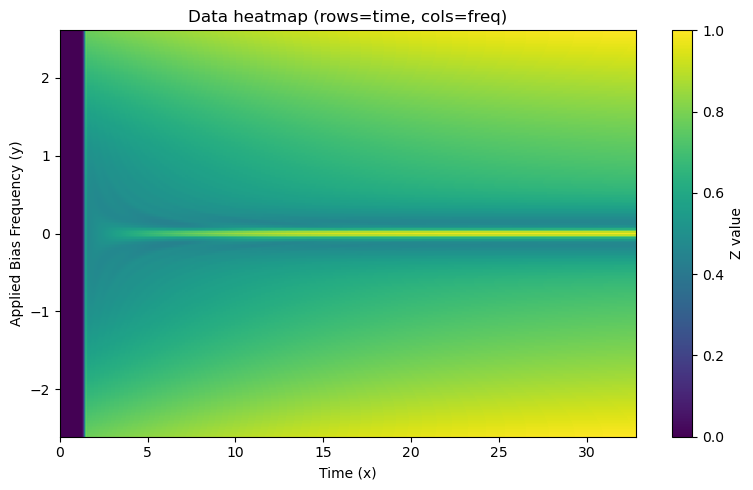

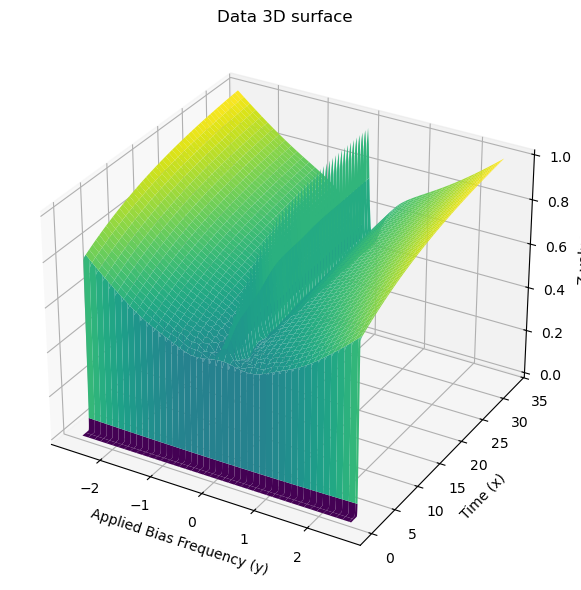

Exp Data


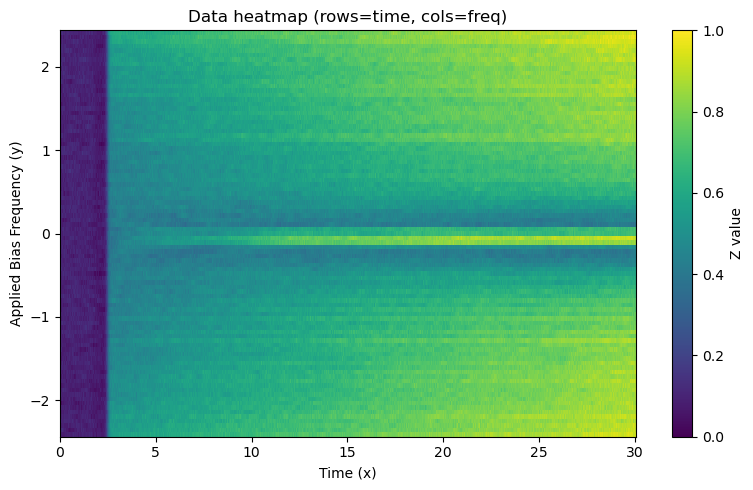

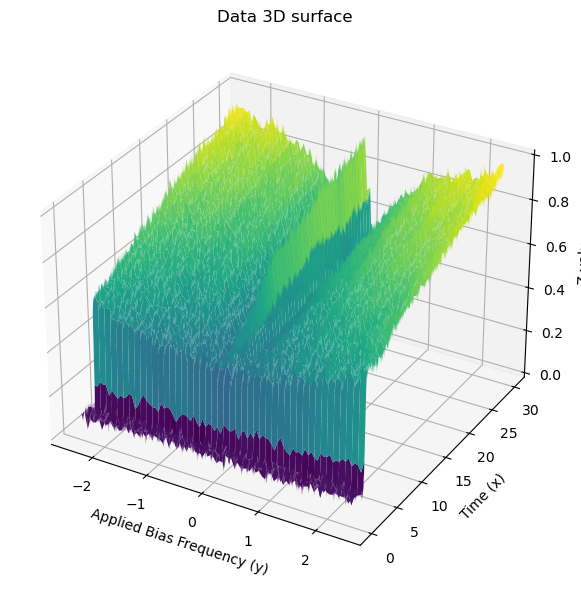

In [14]:
print("Sim Data")
plot_heat_and_surface(t_sim, f_sim, sim_spline(t_sim,f_sim))
print("Exp Data")
plot_heat_and_surface(t_exp, f_bias_axis+F_BIAS_OFFSET_NUISANCE, exp_matrix)

When does simulation signal turn on?

(32800,)
1.37099999999996


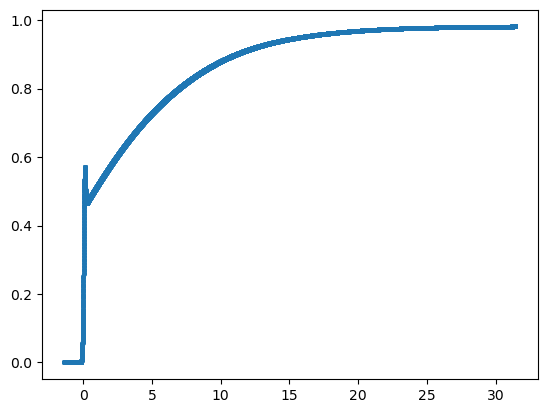

In [15]:
sim_trace_0 = sim_spline(t_sim, f_sim[45]).flatten()
print(sim_trace_0.shape)
t_sim_0, _ = find_pulse_start(sim_trace_0, t_sim, SIM_PULSE_THRESH)
print(t_sim_0)
plt.plot((t_sim-t_sim_0), sim_spline(t_sim, 0),marker ='.',ms=5, label="signal plot", linestyle ='None')
plt.show()                        

When does experiment signal turn on?

(3119,)
2.44000000000004


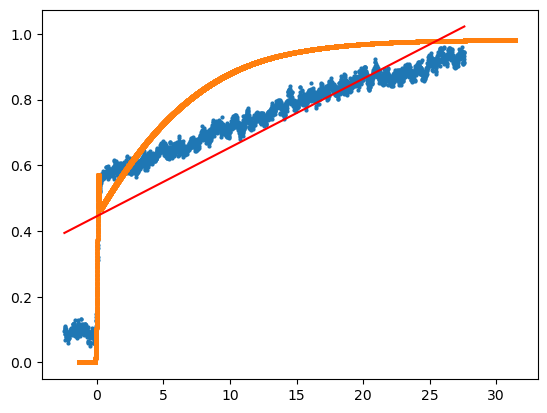

In [16]:
exp_trace_0 = exp_matrix[:,0].flatten()
print(exp_trace_0.shape)
a = 0
b = len(t_exp) - 1
t_exp_0, __ = find_pulse_start(exp_trace_0, t_exp, EXP_PULSE_THRESH)
print(t_exp_0)
plt.plot((t_exp-t_exp_0)[a:b], exp_matrix[a:b, 0], marker ='.',ms=4, label="signal plot", linestyle ='None')
plt.plot((t_sim-t_sim_0), sim_spline(t_sim, 0),marker ='.',ms=5, label="signal plot", linestyle ='None')
slope, intercept = np.polyfit((t_exp-t_exp_0)[a:b], exp_matrix[a:b, 0], 1)
line_x = np.array([min((t_exp-t_exp_0)[a:b]), max((t_exp-t_exp_0)[a:b])])
line_y = slope * line_x + intercept
plt.plot(line_x, line_y, color='red', label=f'Best Fit Line: y={slope:.2f}x + {intercept:.2f}')
plt.show()

Sim Data after alignment of axis


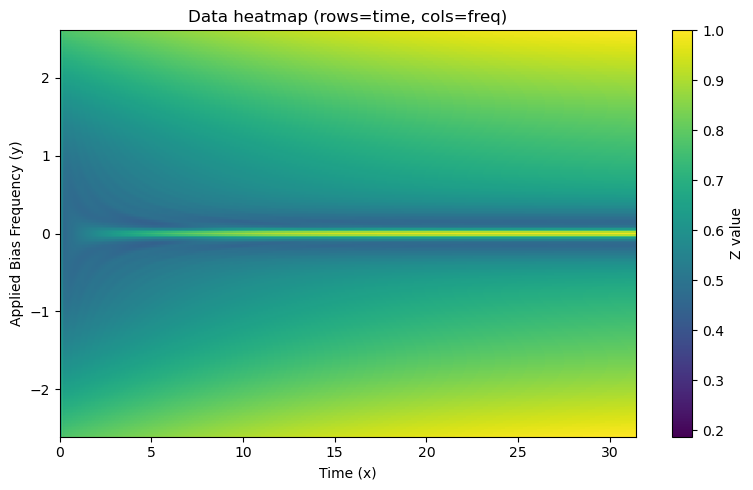

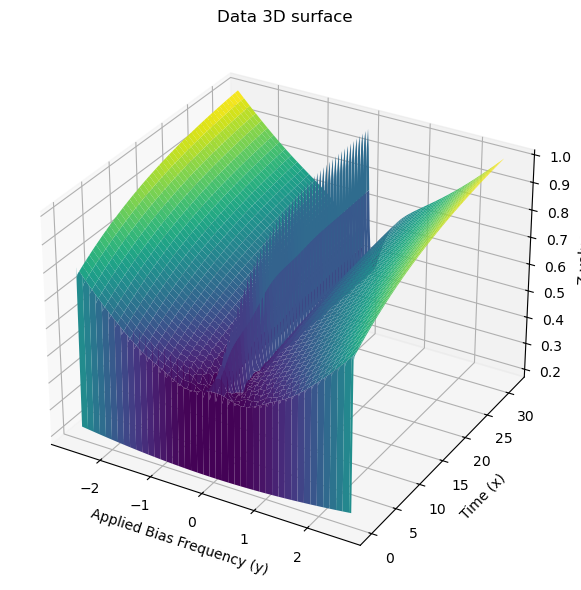

Exp Data after alignment of axis


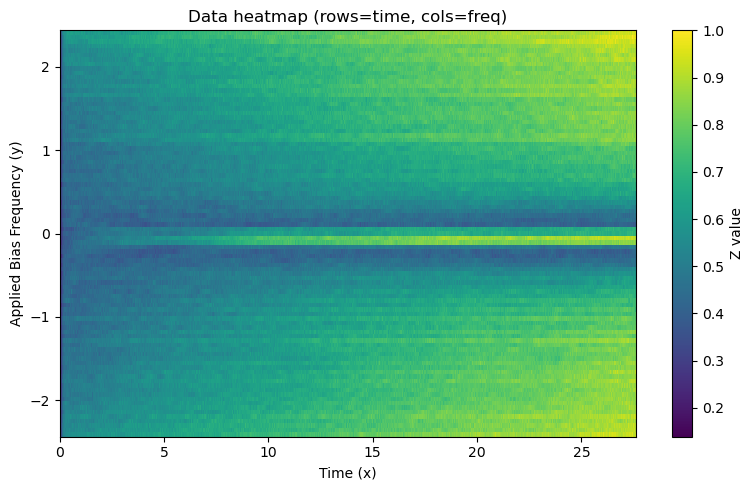

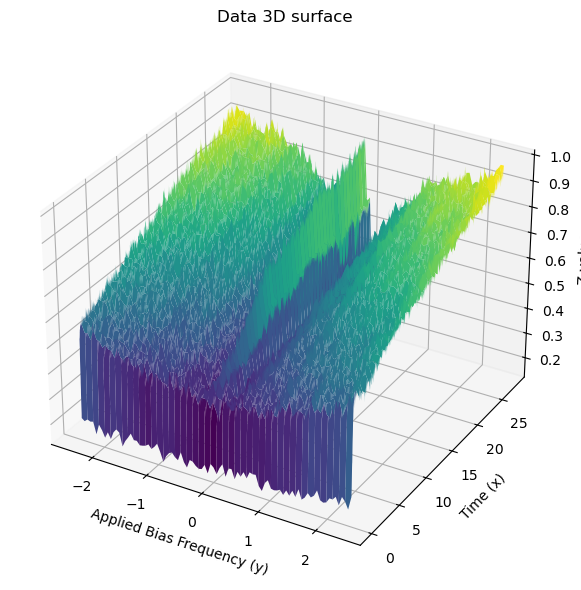

Difference Data after alignment of axis


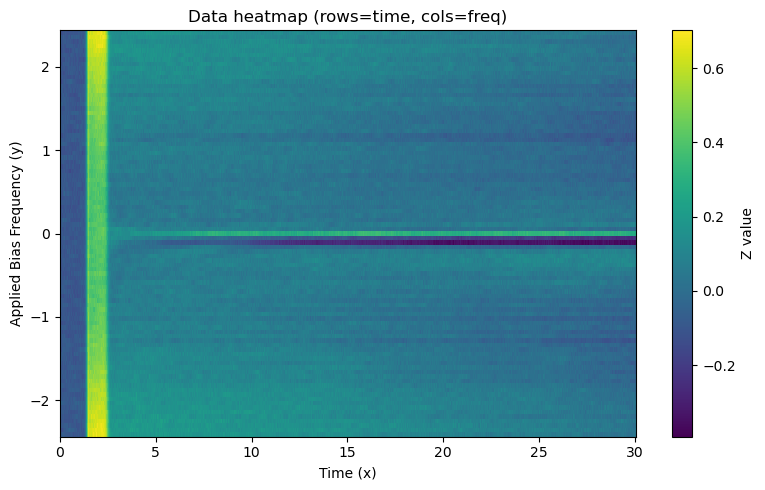

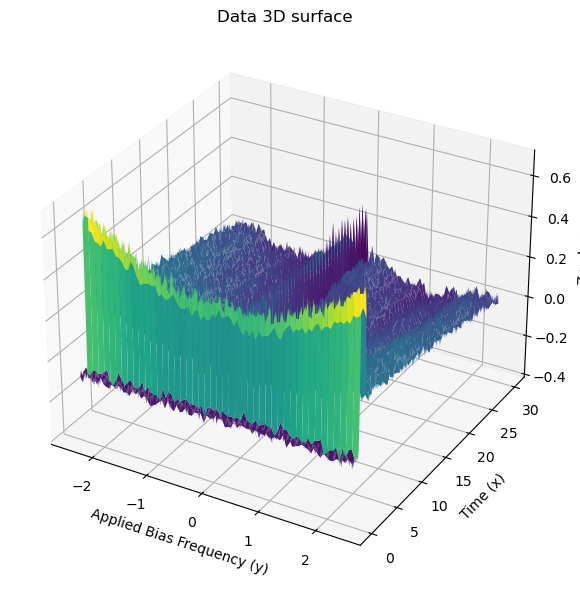

In [17]:
print("Sim Data after alignment of axis")
plot_heat_and_surface((t_sim[_:] -t_sim_0), f_sim, sim_spline(t_sim[_:],f_sim))
print("Exp Data after alignment of axis")
plot_heat_and_surface((t_exp[__:]-t_exp_0), f_bias_axis+F_BIAS_OFFSET_NUISANCE, exp_matrix[__:,])
print("Difference Data after alignment of axis")
plot_heat_and_surface(t_exp, f_bias_axis+F_BIAS_OFFSET_NUISANCE, sim_spline(t_exp,f_bias_axis+F_BIAS_OFFSET_NUISANCE) - exp_matrix)

In [18]:
print("Effective number of experiment time points we have are", len(t_exp[__:]))
print((t_exp[__:]-t_exp_0)[-1])
print(exp_matrix.shape)
print(2866//91)

Effective number of experiment time points we have are 2866
27.60999999999996
(3119, 91)
31


In [19]:
results_longitudinal_estimation = run_experiment_longitudinal_estimation()

Starting Adaptive Experiment...
Loading Simulation from DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_0\transHport_t_vs_Bz_delx_0.01_dely_0.1.csv...
1.702918291091919 was the time taken to load sim data.
Loading Experiment from DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Probe_trans_Exp.csv...
0.08652567863464355 was the time taken to load exp data.

Aligning t=0...
  > Sim Start: 1.3750s
  > Exp Start: 2.4400s
0.004499197006225586 was the time taken to compute the likelihood.| 1920 
 T=5.2s | Bias=0.000 | Est=0.07700 | Res=1.0e-03 0.8035953044891357 was the time taken to compute the KL optimisation. 0.0005125999450683594 was the time taken to compute the likelihood.| 518 
 T=5.4s | Bias=-0.322 | Est=0.44200 | Res=1.0e-03 0.806997537612915 was the time taken to compute the KL optimisation. 0.0 was the time taken to compute the likelihood.| 447 
 T=5.6s | Bias=-0.429 | Est=0.20200 | Res=1.0e-03 0.8105716705322266 was the time taken to compute the KL optimisation. 0.00051

1.3649120330810547 was the time taken to compute the KL optimisation. 0.0005052089691162109 was the time taken to compute the likelihood.| 1510 
 T=6.2s | Bias=-0.536 | Est=0.62680 | Res=1.6e-04 1.3945751190185547 was the time taken to compute the KL optimisation. 0.0 was the time taken to compute the likelihood.| 1698 
 T=6.4s | Bias=-0.590 | Est=0.66300 | Res=1.6e-04 1.443432092666626 was the time taken to compute the KL optimisation. 0.0 was the time taken to compute the likelihood.| 1759 
 T=6.6s | Bias=-0.643 | Est=0.24100 | Res=1.6e-04 1.432044506072998 was the time taken to compute the KL optimisation. 0.0 was the time taken to compute the likelihood.| 23   [ZOOM] Triggered! Mass concentrated in 23 points.|   [ZOOM] Triggered! Mass concentrated in 23 points.|   [ZOOM] Res: 0.000160 -> 0.000026 | Grid Size: 4172| 0.005071401596069336 was the time taken to increase resolution. 
 T=6.8s | Bias=-0.214 | Est=0.08900 | Res=2.6e-05 2.0357272624969482 was the time taken to compute the K

KeyboardInterrupt: 

In [ ]:
t,est,stddev,bias,res,posteriors,bgrid,expectedkl = results_longitudinal_estimation['time'], results_longitudinal_estimation['est'],results_longitudinal_estimation['stddev'], results_longitudinal_estimation['bias'], results_longitudinal_estimation['res'], results_longitudinal_estimation['posteriors'], results_longitudinal_estimation['bgrids'], results_longitudinal_estimation['expectedkl']
result_longitudinal_estimation = {
    'time':np.array(t), 
    'est':np.array(est), 
    'stddev':np.array(stddev), 
    'bias':np.array(bias), 
    'res':np.array(res), 
    'posteriors':np.array(posteriors, dtype=object), 
    'bgrids':np.array(bgrid, dtype=object), 
    'expectedkl':np.array(expectedkl, dtype=object)
}
np.savez_compressed(f"Tests/Actual/CW/Test_{Test}/Test_{Test}_results_longitudinal_estimation.npz", **result_longitudinal_estimation)
print("Results data saved successfully.")

Results data saved successfully.


Results data loaded successfully.
(3119,)


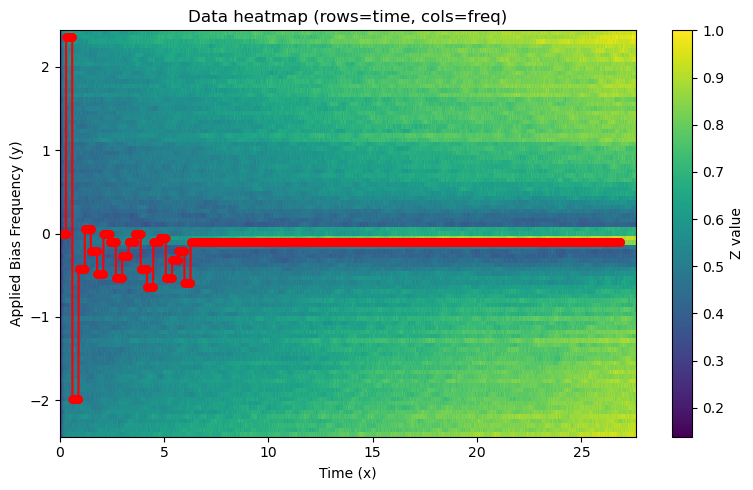

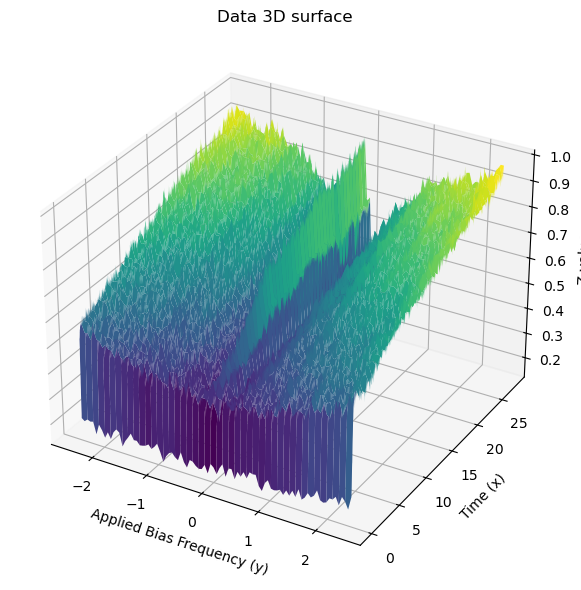

In [ ]:
Test = 6
result_longitudinal_estimation = np.load(f"Tests/Actual/CW/Test_{Test}/Test_{Test}_results.npz", allow_pickle=True)
t,est,stddev,bias,res,posteriors,bgrid,expectedkl = result_longitudinal_estimation['time'], result_longitudinal_estimation['est'],result_longitudinal_estimation['stddev'], result_longitudinal_estimation['bias'], result_longitudinal_estimation['res'], result_longitudinal_estimation['posteriors'], result_longitudinal_estimation['bgrids'], result_longitudinal_estimation['expectedkl']
print("Results data loaded successfully.")
exp_trace_0 = exp_matrix[:,0].flatten()
print(exp_trace_0.shape)
t_exp_0, __ = find_pulse_start(exp_trace_0, t_exp, EXP_PULSE_THRESH)
plot_heat_and_surface((t_exp[__:]-t_exp_0), f_bias_axis, exp_matrix[__:,], trajectory_mode=True,traj_bias = bias, estimation_mode = 'longitudinal')

0.07529832041923012 9.627283367479695e-05
Final posterior area (should be ~1): 1.000000


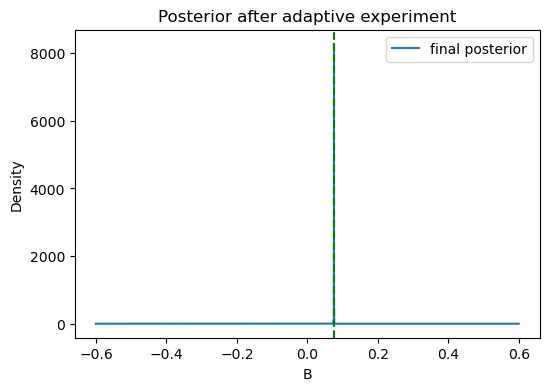

In [ ]:
final_posterior = posteriors[-1]
print(est[-1], stddev[-1])
area = np.trapezoid(final_posterior, x = bgrid[-1])
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(bgrid[-1], final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(
    bgrid[-1][np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

Gif: Posterior

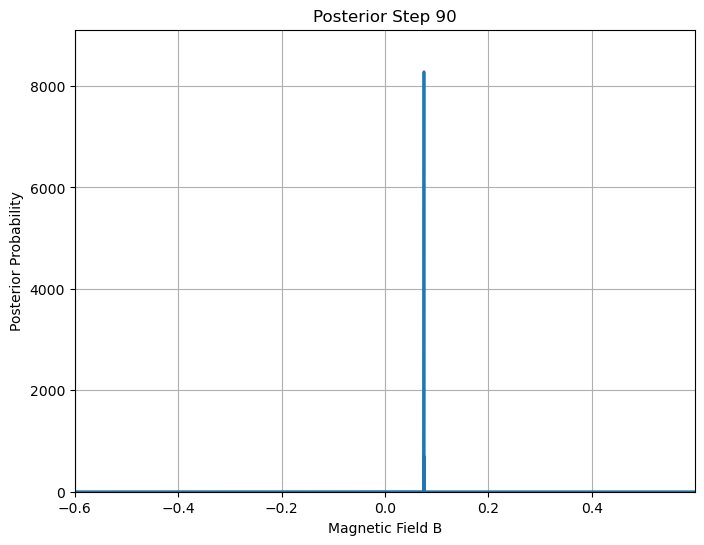

In [ ]:
# Setup figure
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Magnetic Field B")
ax.set_ylabel("Posterior Probability")
ax.grid(True)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation update function
def update(frame):
    # Assuming bgrid and posteriors are lists/arrays of length 90
    x = bgrid[frame]
    y = posteriors[frame]
    
    # Update data
    line.set_data(x, y)
    
    # Rescale axes dynamically to fit the new zoomed/peaked distribution
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, y.max() * 1.1)
    ax.set_title(f"Posterior Step {frame}")
    return line,

# Create animation (interval in milliseconds)
anim = FuncAnimation(fig, update, frames=len(posteriors), 
                     init_func=init, blit=False, interval=100)

# Option 2: Save as GIF (No external dependencies usually)
anim.save(f'Tests/Actual/CW/Test_{Test}/posterior_evolution.gif', writer='pillow', fps=4)

plt.show()

Gif: KL Divergence

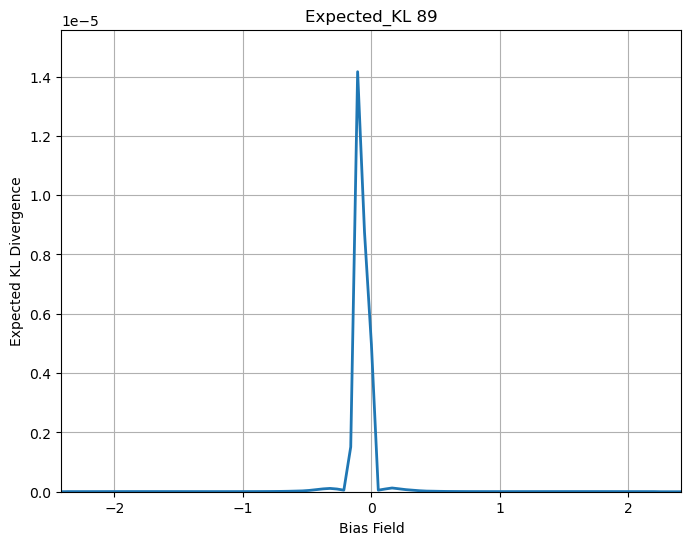

In [ ]:
# Setup figure
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Bias Field")
ax.set_ylabel("Expected KL Divergence")
ax.grid(True)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation update function
def update(frame):
    # Assuming bgrid and posteriors are lists/arrays of length 90
    x = f_bias_axis
    y = expectedkl[frame]
    
    # Update data
    line.set_data(x, y)
    
    # Rescale axes dynamically to fit the new zoomed/peaked distribution
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, y.max() * 1.1)
    ax.set_title(f"Expected_KL {frame}")
    return line,

# Create animation (interval in milliseconds)
anim = FuncAnimation(fig, update, frames=len(expectedkl), 
                     init_func=init, blit=False, interval=100)

# Option 2: Save as GIF (No external dependencies usually)
anim.save(f'Tests/Actual/CW/Test_{Test}/KL_Divergence.gif', writer='pillow', fps=4)

plt.show()

Mode and Std Dev Convergence

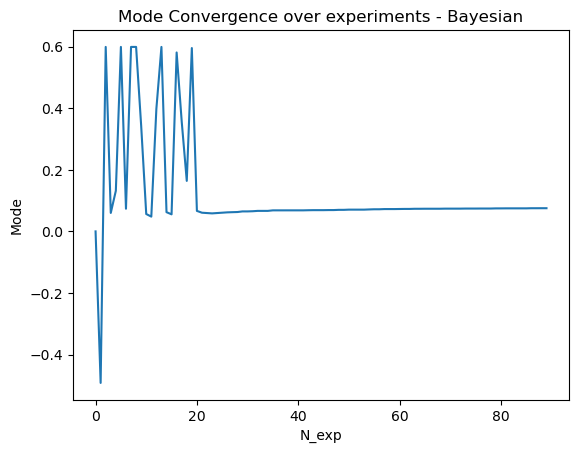

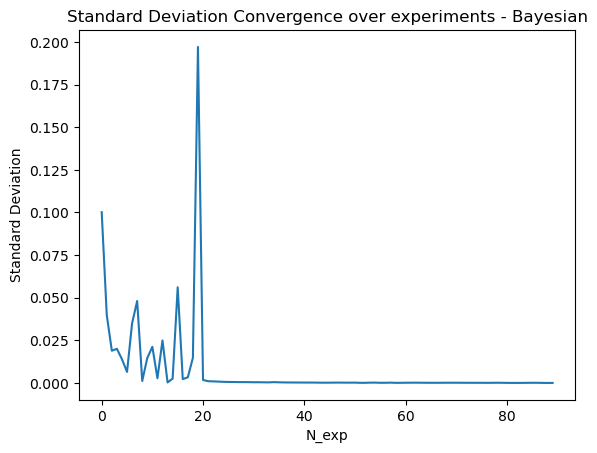

In [ ]:
save_path = os.path.join(new_dir, f'Mode Convergence MAP Test {Test}.png'.format(Test))
plt.plot([i for i in range(len(est))], est, label=f"Mode Convergence")
plt.xlabel("N_exp")
plt.ylabel("Mode")
plt.title("Mode Convergence over experiments - Bayesian")
plt.savefig(save_path)
plt.show()


save_path = os.path.join(new_dir, f'Std Convergence MAP Test {Test}.png'.format(Test))
plt.plot([i for i in range(len(stddev))], stddev, label=f"Standard Deviation Convergence")
plt.xlabel("N_exp")
plt.ylabel("Standard Deviation")
plt.title("Standard Deviation Convergence over experiments - Bayesian")
plt.savefig(save_path)
plt.show()


In [ ]:
fixed_bz_estimate = 0.0

Ok, Y field estimation by interpolation test.... First we'll have a look at the datasets together and try an interpolation method, measure accuracy and then try the same estimation procedure. 

In [ ]:
t_sim, f_sim, by_sim, sim_cube = load_simulation_cube(SIM_FILES_CONFIG_Y_Estimation)

...Loading Simulation Cube Data...
  > Axes Loaded: Time[32800], Freq[91], By[6]
  > Cube Built. Final Shape: (32800, 91, 6)
Time taken to load sim data: 2.448253631591797


In [ ]:
interact(plot_slice, by_idx=IntSlider(min=0, max=len(by_sim)-1, step=1, value=0));

Okay, here we validate the interpolation method. The logic is to check for measure of good fit by leaving a point out in each iteration and extrapolating its value from the rest and seeing how well the prediction is. An average is taken over each such iteration corresponding to each point in the domain.

...Validating Interpolator...
  Hold-out By=0.0 | NRMSE: 90.08%


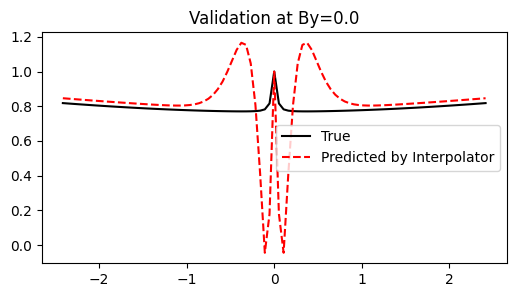

  Hold-out By=0.1 | NRMSE: 6.81%


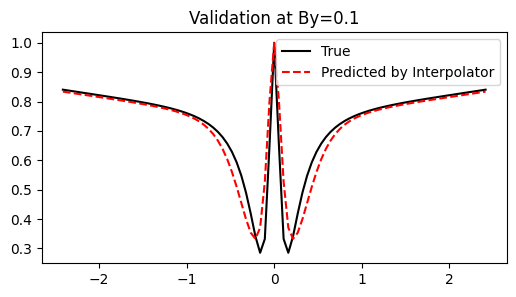

  Hold-out By=0.2 | NRMSE: 4.02%


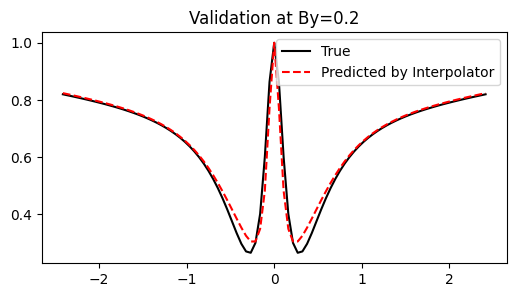

  Hold-out By=0.3 | NRMSE: 1.41%


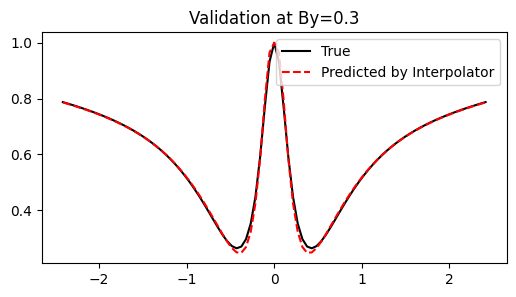

  Hold-out By=0.4 | NRMSE: 2.34%


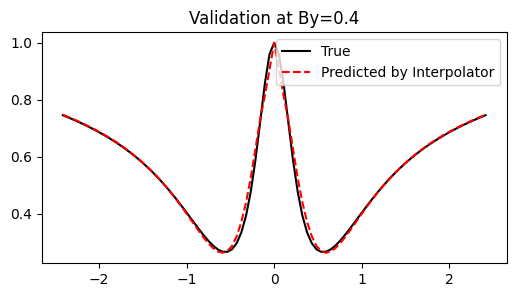

  Hold-out By=0.5 | NRMSE: 9.98%


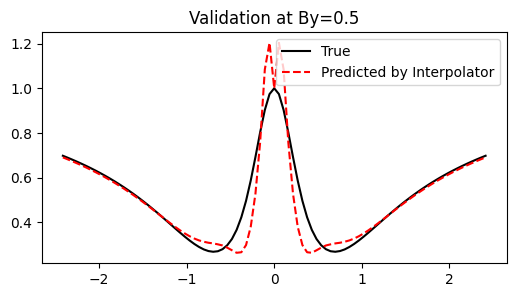

--- Average Error: 19.11% ---
FAIL: Significant non-linearity detected. Need more simulation points.


In [ ]:
validate_interpolator(t_sim, f_sim, by_sim, sim_cube)

In [ ]:
sim_interp = get_final_interpolator(t_sim, f_sim, by_sim, sim_cube)

...Building Final Interpolator...
Time taken to load Interpolator: 0.11026358604431152


Plotting Interpolator Predictions

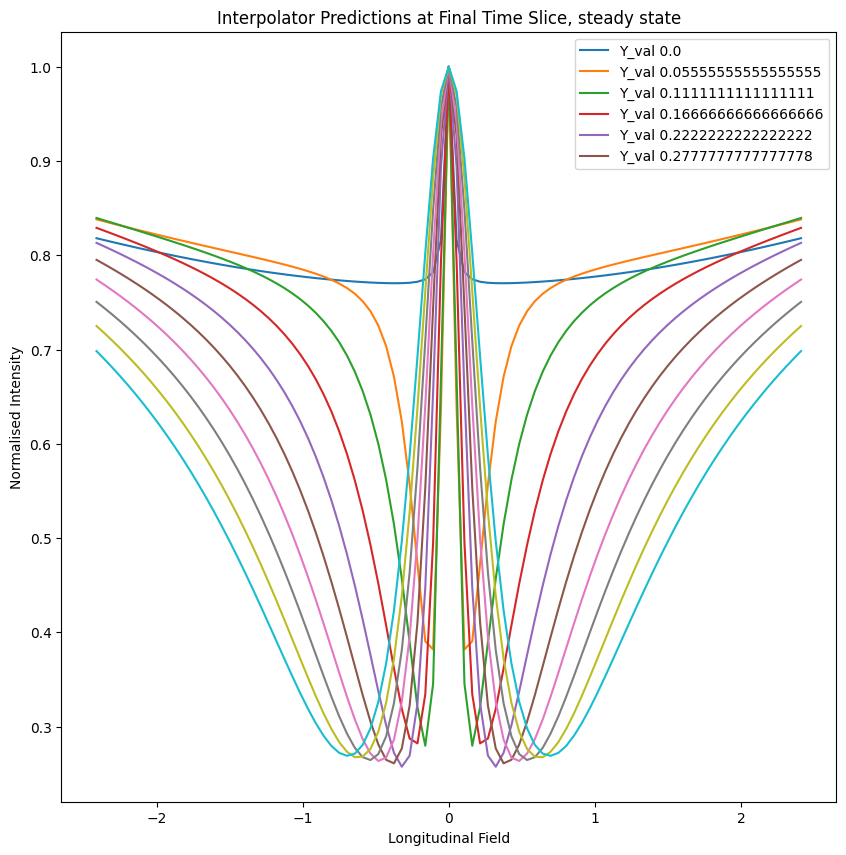

In [ ]:
y_vals = np.linspace(0, 0.5, 10)
Z_mesh, Y_mesh = np.meshgrid(f_sim, y_vals, indexing='ij')
T_mesh = np.full_like(Z_mesh, t_sim[-1])
query_points = np.stack((T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten()), axis=1)
predictions = sim_interp(query_points)
predictions = predictions.reshape(Z_mesh.shape)

plt.figure(figsize=(10,10))
for i in range(len(y_vals)):
    plt.plot(f_sim, predictions[:,i], label=f'Y_val {float(y_vals[i])}')
    plt.ylabel("Normalised Intensity")
    plt.xlabel("Longitudinal Field")
    if i%5==0: plt.legend()
    plt.title("Interpolator Predictions at Final Time Slice, steady state")
plt.show()

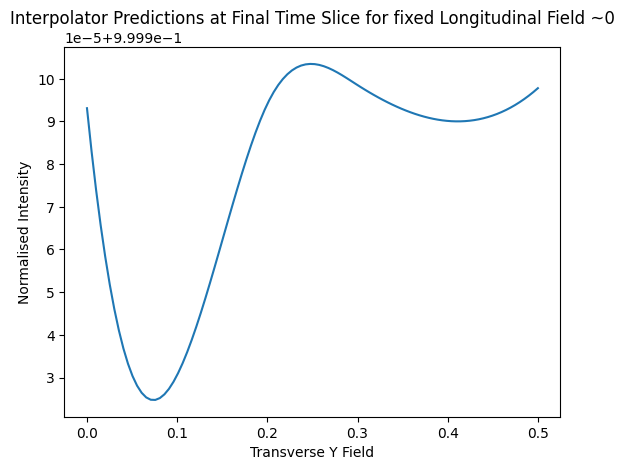

In [ ]:
y_vals = np.linspace(0, 0.5, 100)
Z_mesh, Y_mesh = np.meshgrid(f_sim[np.argmax(sim_cube[-1,:,0])], y_vals, indexing='ij')
T_mesh = np.full_like(Z_mesh, t_sim[-1])
query_points = np.stack((T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten()), axis=1)
predictions = sim_interp(query_points)
predictions = predictions.reshape(Z_mesh.shape)

plt.plot(y_vals, predictions[0,:], label=f'Y_val{float(y_vals[i])}')
plt.ylabel("Normalised Intensity")
plt.xlabel("Transverse Y Field")
plt.title("Interpolator Predictions at Final Time Slice for fixed Longitudinal Field ~0")
plt.show()

Zoom functions are eatly the same right now., please merge them two together and make the code look nice please.

In [ ]:
results_y_estimation = run_experiment_y_estimation()

...Starting Adaptive Experiment for Y Estimation...
...Loading Simulation Cube Data...
  > Axes Loaded: Time[32800], Freq[91], By[6]


  > Cube Built. Final Shape: (32800, 91, 6)
Time taken to load sim data: 2.429305076599121
Loading Experiment from DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_3\transH_t_vs_Bz_alpha2500_delx_0_dely_0.22.csv...
0.35995030403137207 was the time taken to load exp data.
...Building Final Interpolator...
Time taken to load Interpolator: 0.12830901145935059
1935 T=5.2 | BiasZ=0.000 | Est By=0.13800 | Std=0.1237
KL Calculation Time: 0.5228936672210693
97   [ZOOM] Triggered! Mass concentrated in 97 points.|   [ZOOM] Triggered! Mass concentrated in 97 points.|   [ZOOM] Res: 0.000250 -> 0.000040 | Grid Size: 2715| 0.06340932846069336 was the time taken to increase resolution. T=5.4 | BiasZ=0.107 | Est By=0.21850 | Std=0.0037
KL Calculation Time: 0.756746768951416
719 T=5.6 | BiasZ=0.107 | Est By=0.21750 | Std=0.0014
KL Calculation Time: 0.763063907623291
529   [ZOOM] Triggered! Mass concentrated in 529 points.|   [ZOOM] Res: 0.000040 -> 0.000016 | Grid Size: 3649| 0.0022339820861816

In [ ]:
t,est,stddev,bias,res,posteriors,bgrid,expectedkl = results_y_estimation['time'], results_y_estimation['est'],results_y_estimation['stddev'], results_y_estimation['bias'], results_y_estimation['res'], results_y_estimation['posteriors'], results_y_estimation['bgrids'], results_y_estimation['expectedkl']
result_y_estimation = {
    'time':np.array(t), 
    'est':np.array(est), 
    'stddev':np.array(stddev), 
    'bias':np.array(bias), 
    'res':np.array(res), 
    'posteriors':np.array(posteriors, dtype=object), 
    'bgrids':np.array(bgrid, dtype=object), 
    'expectedkl':np.array(expectedkl, dtype=object)
}
np.savez_compressed(f"Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}/Transverse_results.npz", **result_y_estimation)
print("Results data saved successfully.")

Results data saved successfully.


Results data loaded successfully.
(3119,)


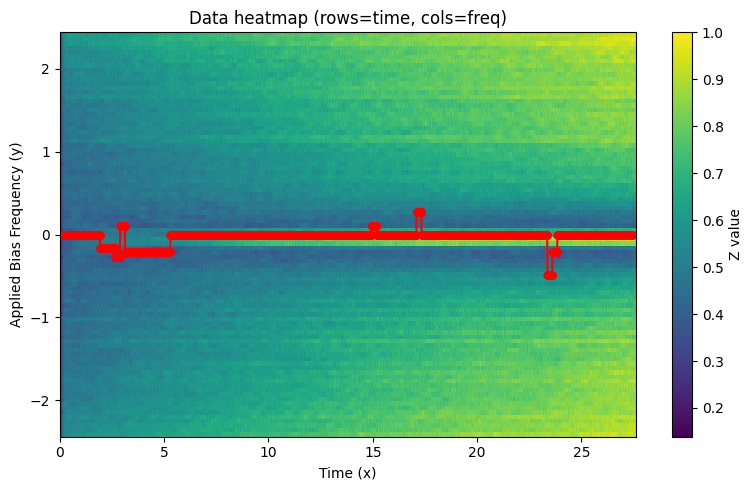

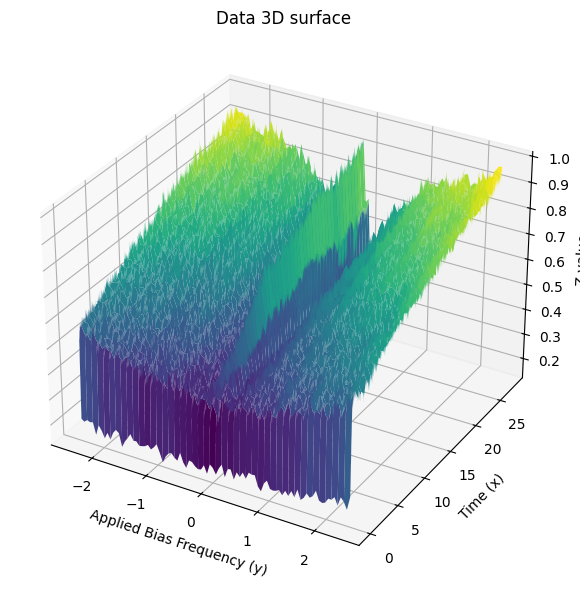

In [ ]:
Test = 3
result_longitudinal_estimation = np.load(f"Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}/Transverse_results.npz", allow_pickle=True)
t,est,stddev,bias,res,posteriors,bgrid,expectedkl = result_longitudinal_estimation['time'], result_longitudinal_estimation['est'],result_longitudinal_estimation['stddev'], result_longitudinal_estimation['bias'], result_longitudinal_estimation['res'], result_longitudinal_estimation['posteriors'], result_longitudinal_estimation['bgrids'], result_longitudinal_estimation['expectedkl']
print("Results data loaded successfully.")
exp_trace_0 = exp_matrix[:,0].flatten()
print(exp_trace_0.shape)
t_exp_0, __ = find_pulse_start(exp_trace_0, t_exp, EXP_PULSE_THRESH)
plot_heat_and_surface((t_exp[__:]-t_exp_0), f_bias_axis, exp_matrix[__:,], trajectory_mode=True,traj_bias = bias)

0.21725 0.00019814426444576865
Final posterior area (should be ~1): 1.000000


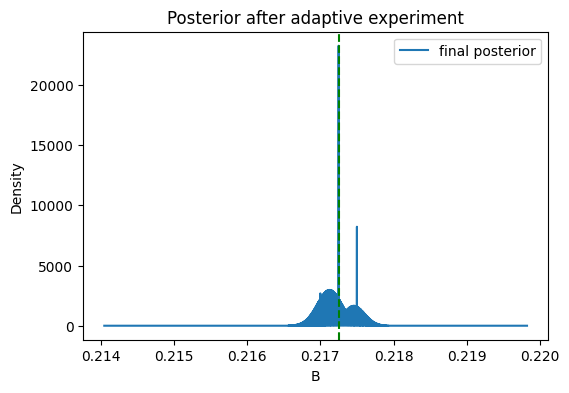

In [ ]:
final_posterior = posteriors[-1]
print(est[-1], stddev[-1])
area = np.trapezoid(final_posterior, x = bgrid[-1])
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(bgrid[-1][np.argmax(final_posterior) - 1000:np.argmax(final_posterior)+1000], final_posterior[np.argmax(final_posterior) - 1000:np.argmax(final_posterior)+1000], label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(
    bgrid[-1][np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

Posterior GIF

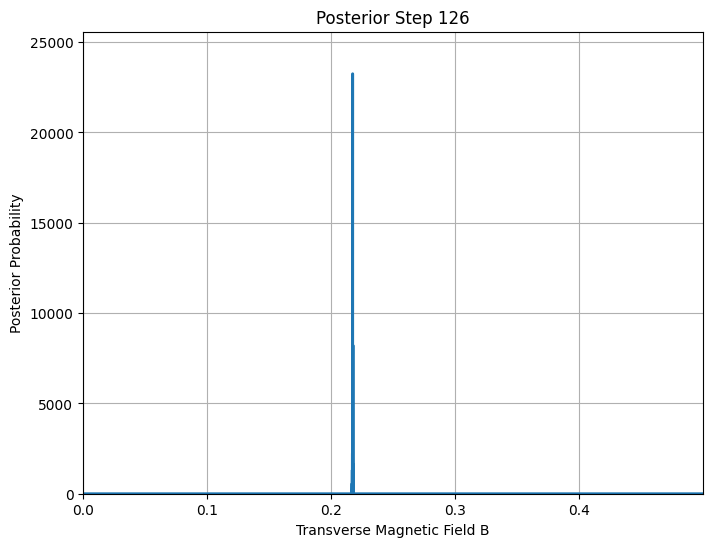

In [ ]:
# Setup figure
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Transverse Magnetic Field B")
ax.set_ylabel("Posterior Probability")
ax.grid(True)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation update function
def update(frame):
    # Assuming bgrid and posteriors are lists/arrays of length 90
    x = bgrid[frame]
    y = posteriors[frame]
    
    # Update data
    line.set_data(x, y)
    
    # Rescale axes dynamically to fit the new zoomed/peaked distribution
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, y.max() * 1.1)
    ax.set_title(f"Posterior Step {frame}")
    return line,

# Create animation (interval in milliseconds)
anim = FuncAnimation(fig, update, frames=len(posteriors), 
                     init_func=init, blit=False, interval=100)

# Option 2: Save as GIF (No external dependencies usually)
anim.save(f'Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}/Transverse_field_posterior_evolution.gif', writer='pillow', fps=4)

plt.show()

KL Divergence GIF

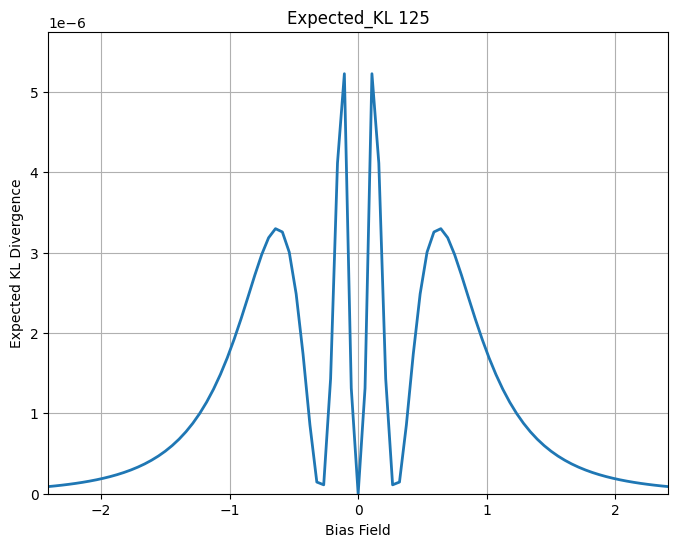

In [ ]:
# Setup figure
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Bias Field")
ax.set_ylabel("Expected KL Divergence")
ax.grid(True)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation update function
def update(frame):
    # Assuming bgrid and posteriors are lists/arrays of length 90
    x = f_bias_axis
    y = expectedkl[frame]
    
    # Update data
    line.set_data(x, y)
    
    # Rescale axes dynamically to fit the new zoomed/peaked distribution
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, y.max() * 1.1)
    ax.set_title(f"Expected_KL {frame}")
    return line,

# Create animation (interval in milliseconds)
anim = FuncAnimation(fig, update, frames=len(expectedkl), 
                     init_func=init, blit=False, interval=100)

# Option 2: Save as GIF (No external dependencies usually)
anim.save(f'Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}/Transverse_Field_KL_Divergence.gif', writer='pillow', fps=4)

plt.show()

Summary Stats

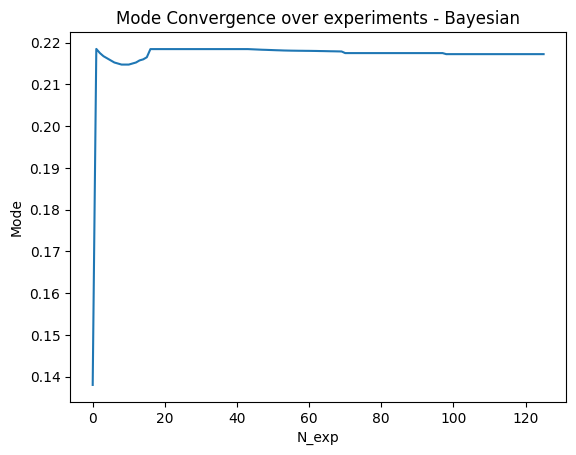

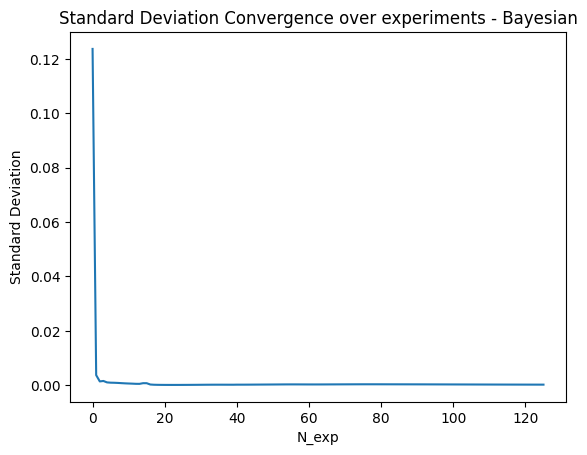

In [ ]:
save_path = os.path.join(new_dir_y, f'Mode Convergence MAP Transverse Field.png'.format(Test))
plt.plot([i for i in range(len(est))], est, label=f"Mode Convergence")
plt.xlabel("N_exp")
plt.ylabel("Mode")
plt.title("Mode Convergence over experiments - Bayesian")
plt.savefig(save_path)
plt.show()


save_path = os.path.join(new_dir_y, f'Std Convergence MAP Transverse Field.png'.format(Test))
plt.plot([i for i in range(len(stddev))], stddev, label=f"Standard Deviation Convergence")
plt.xlabel("N_exp")
plt.ylabel("Standard Deviation")
plt.title("Standard Deviation Convergence over experiments - Bayesian")
plt.savefig(save_path)
plt.show()


In [ ]:
# start a loop
# estimate Bz: dataset 0's sim
# estimate By: dataset 2's sim

def run_experiment_z_estimation():
    print("Starting Adaptive Experiment...") #! to be deleted
    
    # Load and align data
    t_sim, f_sim, sim_spline = load_simulation(SIM_FILES_Longitudinal_Estimation)
    t_exp, f_bias_axis, exp_matrix = load_experiment(EXP_FILES)
    f_bias_axis += F_BIAS_OFFSET_NUISANCE
    
    print("\nAligning t=0...")
    t_sim_0, _ = find_pulse_start(sim_spline(t_sim, 0).flatten(), t_sim, SIM_PULSE_THRESH)
    t_exp_0, __ = find_pulse_start(exp_matrix[:, 0], t_exp, EXP_PULSE_THRESH)
    print(f"  > Sim Start: {t_sim_0:.4f}s | Exp Start: {t_exp_0:.4f}s")
    
    # Initialize grid and posterior
    b_grid_gpu = cp.arange(*B_UNK_INITIAL_RANGE, INITIAL_RESOLUTION)
    posterior_gpu = cp.full_like(b_grid_gpu, 1.0 / (B_UNK_INITIAL_RANGE[1] - B_UNK_INITIAL_RANGE[0]))
    curr_res = INITIAL_RESOLUTION
    
    # Initialize state
    curr_time, curr_bias = 5.0, 0.0
    history = {k: [] for k in ['time', 'est', 'stddev', 'bias', 'res', 'posteriors', 'bgrids', 'expectedkl']}
    history['posteriors'].append(posterior_gpu.get())
    history['bgrids'].append(b_grid_gpu.get())
    
    start_wall = time.time()
    
    # Main loop
    while curr_time < MAX_TIME:
        t_next = curr_time + T_STEP
        idx_start = np.searchsorted(t_exp, t_exp_0 + curr_time)
        idx_end = np.searchsorted(t_exp, t_exp_0 + t_next)
        if idx_start >= idx_end: break
        
        bias_idx = np.argmin(np.abs(f_bias_axis - curr_bias))
        y_obs = exp_matrix[idx_start:idx_end, bias_idx]
        t_sim_eval = (t_exp[idx_start:idx_end] - t_exp_0) + t_sim_0
        
        # Update posterior
        likelihood = calculate_likelihood_gpu(y_obs, t_sim_eval, curr_bias, b_grid_gpu, sim_spline, SIGMA_NOISE)
        posterior_gpu = (posterior_gpu * likelihood) / cp.trapz(posterior_gpu * likelihood, x=b_grid_gpu)
        
        # Adaptive zoom
        posterior_gpu, b_grid_gpu, curr_res = check_and_apply_zoom(posterior_gpu, b_grid_gpu, curr_res)
        
        # Record statistics
        mode, stddev = calculate_summary_stats(posterior_gpu, b_grid_gpu)
        for k, v in zip(['time', 'est', 'stddev', 'bias', 'res', 'posteriors', 'bgrids'], 
                        [t_next, mode, stddev, curr_bias, curr_res, posterior_gpu.get(), b_grid_gpu.get()]):
            history[k].append(v)
        
        print(f"\nT={t_next:.1f}s | Bias={curr_bias:.3f} | Est={mode:.5f} | Res={curr_res:.1e}", end=" ")
        
        # Adapt control
        curr_bias, expectedkl = calculate_kl_divergence_gpu(
            posterior_gpu, b_grid_gpu, sim_spline, 
            t_next + t_sim_0, t_next + T_STEP + t_sim_0, 
            f_bias_axis, batch_size=131
        )
        history['expectedkl'].append(expectedkl.get())
        curr_time = t_next
    
    print(f"\nDone in {time.time() - start_wall:.2f}s")
    return history


In [ ]:
# Run

def altopt(num_iter = 5):
    # estimate
    bz_history = []
    by_history = []

    # estimate Bz
    results = run_experiment_longitudinal_estimation()
    fixed_bz_estimate = results['est'][-1]
    bz_history.append(fixed_bz_estimate)
    print(f"Estimated Bz: {fixed_bz_estimate}")
    for i in range(num_iter):
        # estimate By
        results_by = run_experiment_y_estimation()
        fixed_by_estimate = results_by['est'][-1]
        by_history.append(fixed_by_estimate)
        print(f"Estimated By: {fixed_by_estimate}")

        # estimate Bz again with fixed By
        results = run_experiment_z_estimation()
        fixed_bz_estimate = results['est'][-1]
        bz_history.append(fixed_bz_estimate)
        print(f"Estimated Bz: {fixed_bz_estimate}")

def plot_altopt(bz_history, by_history):
    iterations_bz = list(range(len(bz_history)))
    iterations_by = list(range(len(by_history)))

    plt.figure(figsize=(10, 5))

    # Plot for Bz
    plt.subplot(1, 2, 1)
    plt.plot(iterations_bz, bz_history, marker='o')
    plt.title('Convergence of Bz Estimates')
    plt.xlabel('Iteration')
    plt.ylabel('Estimated Bz Value')
    plt.grid(True)

    # Plot for By
    plt.subplot(1, 2, 2)
    plt.plot(iterations_by, by_history, marker='o', color='orange')
    plt.title('Convergence of By Estimates')
    plt.xlabel('Iteration')
    plt.ylabel('Estimated By Value')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


...Starting Alternating Optimization...
Loading Simulation from DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_0\transHport_t_vs_Bz_delx_0.01_dely_0.1.csv...
1.6646537780761719 was the time taken to load sim data.
...Loading Simulation Cube Data...
  > Axes Loaded: Time[32800], Freq[91], By[6]
  > Cube Built. Final Shape: (32800, 91, 6)
Time taken to load sim data: 2.4525020122528076
Loading Experiment from DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Probe_trans_Exp.csv...
0.08747506141662598 was the time taken to load exp data.
...Building Final Interpolator...
Time taken to load Interpolator: 0.1761009693145752

[Iter 0 | BZ] 0.00850820541381836 was the time taken to compute the likelihood.| 1920 Bz=0.07700±0.35467
0.896803617477417 was the time taken to compute the KL optimisation. 
[Iter 1 | BZ] 0.0 was the time taken to compute the likelihood.| 518 Bz=0.44200±0.09497
0.7838430404663086 was the time taken to compute the KL optimisation. 
[Iter 2 | BZ] 0.0 was the tim

ValueError: operands could not be broadcast together with shapes (2000,) (3089,) (2000,)